# Phase 2 Feature List Validation and Model Comparison

This notebook evaluates several packet-level feature lists for Phase 2 unsupervised anomaly detection.

The goal is to identify a practical feature candidate that performs consistently across different anomaly-detection models, hyperparameter settings, and random seeds.

The workflow includes:

1. sampling 200,000 benign packets and 6,000 attack packets;
2. deriving protocol-aware HTTP, DNS, and XSS features;
3. creating group-separated training, validation, and final holdout sets;
4. comparing several fixed feature candidates;
5. evaluating K-Means, Isolation Forest, PCA + K-Means, Autoencoder, and Autoencoder + K-Means;
6. checking stability across multiple random seeds;
7. selecting thresholds for a high-F1 operating point and a coverage-oriented operating point;
8. evaluating the selected pipeline once on the untouched final holdout;
9. exporting packet anomaly scores and initial alerts for Phase 3.

Packet labels are not passed into unsupervised model fitting. Development labels are used only for offline feature-list comparison, model selection, and threshold selection. Final-holdout labels are used only for the final performance report.

## Required packages and input files

Install the required packages before running:

```bash
pip install pandas numpy matplotlib pyarrow scipy scikit-learn
```

When available, the notebook also reads:

```text
results/feature_audit/candidate_feature_sets.json
```

The packet-level Parquet files are discovered automatically from the project data directory.

In [1]:
from __future__ import annotations

from pathlib import Path
import itertools
import json
import math
import re
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from IPython.display import display

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_recall_curve,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import RobustScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 180)

## 1. Experiment configuration

This section defines:

- packet sample sizes;
- attack-class allocation;
- sampling and split seeds;
- model hyperparameters;
- threshold constraints;
- random seeds used for stability testing.

A fresh sample and split are used so that this validation does not reuse the test split examined in earlier experiments.

In [2]:
PACKET_DATA_DIR = None

# Fresh sample and split seeds for the final decision experiment.
BENIGN_ROWS = 200_000
ATTACK_ROWS = 6_000
MIN_ATTACK_ROWS_PER_CLASS = 800
SAMPLE_SEED = 20260712
SPLIT_SEED = 918273

ATTACK_TYPES = [
    "ddos_http",
    "dos_http",
    "dns_spoofing",
    "xss",
    "brute_force",
]

# 60% development train, 20% validation, 20% untouched final holdout.
TEMPORARY_FRACTION = 0.40
HOLDOUT_WITHIN_TEMPORARY = 0.50

# Stage-1 search uses a smaller benign subset for speed.
SEARCH_TRAIN_BENIGN_ROWS = 45_000
SEARCH_VALIDATION_BENIGN_ROWS = 18_000

# Threshold rules.
HIGH_F1_FPR_CAP = 0.01
COVERAGE_FPR_CAP = 0.02
THRESHOLD_QUANTILES = np.linspace(0.70, 0.9995, 320)

# K-Means.
K_VALUES = [2, 3, 4, 6, 8]
KMEANS_BATCH_SIZE = 8192
KMEANS_MAX_ITER = 120
KMEANS_N_INIT = 5

# Isolation Forest.
IFOREST_TREES = 300
IFOREST_MAX_SAMPLES = 50_000

# PCA and autoencoder.
PCA_VARIANCE_VALUES = [0.85, 0.90, 0.95]
AUTOENCODER_BOTTLENECKS = [3, 5, 8]
AUTOENCODER_MAX_ITER = 100

# Stability and final score ensemble.
MODEL_SEEDS = [42, 143, 244]
FINALIST_FEATURE_LISTS = 2
TOP_PIPELINES_FOR_STABILITY = 3

RUN_AUTOENCODER = True
SAVE_RESULTS = True

## 2. Candidate feature lists

Five fixed feature candidates are compared:

- the original Top-10 numeric list;
- the previously optimized 15-feature list;
- the original Top-10 with protocol-aware features;
- the optimized 15-feature list with additional XSS indicators;
- a broader balanced 20-feature candidate.

Every candidate is evaluated using the same sample, split, preprocessing, model families, and threshold rules.

In [3]:
ORIGINAL_TOP10 = [
    "channel_60_count",
    "channel_1_var",
    "tcp_window_size",
    "inter_arrival_time",
    "stream_jitter_1_sum",
    "src_ip_mac_60_mean",
    "stream_60_count",
    "min_e",
    "l3_ip_dst_count",
    "time_since_previously_displayed_frame",
]

PREVIOUS_OPTIMIZED15 = [
    "src_ip_5_mean",
    "stream_60_count",
    "stream_jitter_60_sum",
    "is_dns_packet",
    "channel_10_count",
    "http_uri_special_char_count",
    "tcp_window_size",
    "inter_arrival_time",
    "max_p",
    "user_agent_length",
    "is_http_packet",
    "src_ip_mac_60_var",
    "l3_ip_dst_count",
    "http_uri_parameter_count",
    "highest_layer_is_tls",
]

TOP10_PROTOCOL18 = ORIGINAL_TOP10 + [
    "is_dns_packet",
    "is_http_packet",
    "http_uri_special_char_count",
    "http_uri_parameter_count",
    "http_uri_xss_token_count",
    "http_uri_has_xss_pattern",
    "user_agent_length",
    "highest_layer_is_tls",
]

OPTIMIZED15_XSS19 = PREVIOUS_OPTIMIZED15 + [
    "http_uri_xss_token_count",
    "http_uri_has_xss_pattern",
    "http_uri_angle_bracket_count",
    "http_uri_percent_encoded_count",
]

BALANCED20 = [
    "channel_60_count",
    "channel_1_var",
    "channel_10_count",
    "src_ip_5_mean",
    "src_ip_mac_60_var",
    "stream_60_count",
    "stream_jitter_60_sum",
    "tcp_window_size",
    "inter_arrival_time",
    "max_p",
    "min_e",
    "l3_ip_dst_count",
    "time_since_previously_displayed_frame",
    "is_dns_packet",
    "is_http_packet",
    "highest_layer_is_tls",
    "user_agent_length",
    "http_uri_special_char_count",
    "http_uri_parameter_count",
    "http_uri_xss_has_pattern",
]

# Correct the final alias without changing the readable list above.
BALANCED20[-1] = "http_uri_has_xss_pattern"

CANDIDATE_FEATURE_LISTS = {
    "original_top10": ORIGINAL_TOP10,
    "previous_optimized15": PREVIOUS_OPTIMIZED15,
    "top10_protocol18": TOP10_PROTOCOL18,
    "optimized15_xss19": OPTIMIZED15_XSS19,
    "balanced20": BALANCED20,
}

display(
    pd.DataFrame(
        [
            {
                "feature_list": name,
                "feature_count": len(features),
                "features": features,
            }
            for name, features in CANDIDATE_FEATURE_LISTS.items()
        ]
    )
)

,feature_list,feature_count,features
0,original_top10,10,"[channel_60_count, channel_1_var, tcp_window_size, inter_arrival_time, stream_jitter_1_sum, src_ip_mac_60_mean, stream_60_count, min_e, l3_ip_dst_count, time_since_previously_d..."
1,previous_optimized15,15,"[src_ip_5_mean, stream_60_count, stream_jitter_60_sum, is_dns_packet, channel_10_count, http_uri_special_char_count, tcp_window_size, inter_arrival_time, max_p, user_agent_leng..."
2,top10_protocol18,18,"[channel_60_count, channel_1_var, tcp_window_size, inter_arrival_time, stream_jitter_1_sum, src_ip_mac_60_mean, stream_60_count, min_e, l3_ip_dst_count, time_since_previously_d..."
3,optimized15_xss19,19,"[src_ip_5_mean, stream_60_count, stream_jitter_60_sum, is_dns_packet, channel_10_count, http_uri_special_char_count, tcp_window_size, inter_arrival_time, max_p, user_agent_leng..."
4,balanced20,20,"[channel_60_count, channel_1_var, channel_10_count, src_ip_5_mean, src_ip_mac_60_var, stream_60_count, stream_jitter_60_sum, tcp_window_size, inter_arrival_time, max_p, min_e, ..."


Sparse XSS indicators are kept intentionally.

Features such as `http_uri_has_xss_pattern` may be zero for nearly every benign packet but nonzero for a small number of attack packets. In intrusion detection, a rare indicator can still provide useful evidence and should not automatically be removed as a near-constant feature.

## 3. Dataset discovery

This section searches the project directories for packet-level Parquet files corresponding to:

- benign traffic;
- DDoS HTTP flood;
- DoS HTTP flood;
- DNS spoofing;
- XSS;
- dictionary brute force.

The displayed inventory confirms the discovered files, row counts, column counts, and source paths before sampling begins.

In [4]:
def find_repo_root() -> Path:
    current = Path.cwd().resolve()

    for candidate in [current, *current.parents]:
        expected = (
            candidate
            / "data"
            / "raw"
            / "packetFeatures_datasets"
        )

        if expected.exists():
            return candidate

    return current.parent if current.name.lower() == "notebooks" else current


REPO_ROOT = find_repo_root()

search_roots = [
    REPO_ROOT / "data" / "raw" / "packetFeatures_datasets",
    REPO_ROOT,
    Path("/mnt/data"),
]

if PACKET_DATA_DIR is not None:
    search_roots.insert(0, Path(PACKET_DATA_DIR).resolve())

file_patterns = {
    "benign": ["BenignTraffic*.parquet"],
    "ddos_http": [
        "DDoS-HTTP_Flood-*.parquet",
        "DDoS-HTTP_Flood*.parquet",
    ],
    "dos_http": ["DoS-HTTP_Flood*.parquet"],
    "dns_spoofing": ["DNS_Spoofing*.parquet"],
    "xss": ["XSS.parquet"],
    "brute_force": ["DictionaryBruteForce*.parquet"],
}

packet_files: dict[str, list[Path]] = {}

for traffic_type, patterns in file_patterns.items():
    matches = []

    for root in search_roots:
        if not root.exists():
            continue

        for pattern in patterns:
            matches.extend(root.rglob(pattern))

    packet_files[traffic_type] = sorted(
        {
            path.resolve()
            for path in matches
            if "Flow" not in path.name
        }
    )

inventory_rows = []

for traffic_type, paths in packet_files.items():
    for path in paths:
        parquet_file = pq.ParquetFile(path)

        inventory_rows.append(
            {
                "traffic_type": traffic_type,
                "file": path.name,
                "rows": parquet_file.metadata.num_rows,
                "columns": parquet_file.metadata.num_columns,
                "path": str(path),
            }
        )

file_inventory = pd.DataFrame(inventory_rows)
display(file_inventory)

missing_types = [
    traffic_type
    for traffic_type, paths in packet_files.items()
    if not paths
]

if missing_types:
    raise FileNotFoundError(
        "Missing packet files for: " + ", ".join(missing_types)
    )

reference_schema = pq.ParquetFile(
    packet_files["benign"][0]
).schema_arrow

schema_names = reference_schema.names

,traffic_type,file,rows,columns,path
0,benign,BenignTraffic.parquet,297063,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\BenignTraffic.parquet
1,benign,BenignTraffic1.parquet,295201,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\BenignTraffic1.parquet
2,benign,BenignTraffic2.parquet,295200,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\BenignTraffic2.parquet
3,benign,BenignTraffic3.parquet,295334,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\BenignTraffic3.parquet
4,ddos_http,DDoS-HTTP_Flood-.parquet,290346,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\DDoS-HTTP_Flood-.parquet
5,dos_http,DoS-HTTP_Flood.parquet,156328,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\DoS-HTTP_Flood.parquet
6,dos_http,DoS-HTTP_Flood1.parquet,157711,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\DoS-HTTP_Flood1.parquet
7,dns_spoofing,DNS_Spoofing.parquet,296025,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\DNS_Spoofing.parquet
8,xss,XSS.parquet,40101,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\XSS.parquet
9,brute_force,DictionaryBruteForce.parquet,131477,135,C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\data\raw\packetFeatures_datasets\DictionaryBruteForce.parquet


In [5]:
candidate_set_paths = [
    REPO_ROOT / "results" / "feature_audit" / "candidate_feature_sets.json",
    REPO_ROOT / "feature_audit_outputs" / "candidate_feature_sets.json",
    REPO_ROOT / "candidate_feature_sets.json",
    Path("/mnt/data/candidate_feature_sets.json"),
]

candidate_set_path = next(
    (path for path in candidate_set_paths if path.exists()),
    None,
)

if candidate_set_path is not None:
    candidate_sets = json.loads(
        candidate_set_path.read_text(encoding="utf-8")
    )

    broad_numeric_features = list(
        candidate_sets.get("set_b_reduced_numeric", [])
    )

    print("Candidate-set file:", candidate_set_path)

else:
    broad_numeric_features = [
        field.name
        for field in reference_schema
        if (
            pa.types.is_integer(field.type)
            or pa.types.is_floating(field.type)
            or pa.types.is_boolean(field.type)
        )
    ]

    print("Using numeric-schema fallback.")

broad_numeric_features = [
    feature
    for feature in broad_numeric_features
    if feature in schema_names
    and feature not in {"stream", "src_port", "dst_port"}
]

raw_protocol_columns = [
    column
    for column in [
        "http_uri",
        "user_agent",
        "dns_server",
        "highest_layer",
        "http_content_type",
        "http_request_method",
        "handshake_version",
        "tls_server",
        "dns_query_type",
    ]
    if column in schema_names
]

raw_candidate_features = sorted(
    {
        feature
        for features in CANDIDATE_FEATURE_LISTS.values()
        for feature in features
        if feature in schema_names
    }
)

columns_to_read = sorted(
    set(raw_candidate_features)
    .union(raw_protocol_columns)
    .union({"stream"})
)

print("Raw candidate columns:", len(raw_candidate_features))
print("Raw protocol columns:", raw_protocol_columns)

Candidate-set file: C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\results\feature_audit\candidate_feature_sets.json
Raw candidate columns: 15
Raw protocol columns: ['http_uri', 'user_agent', 'dns_server', 'highest_layer', 'http_content_type', 'http_request_method', 'handshake_version', 'tls_server', 'dns_query_type']


## 4. Assignment-sized packet sampling

The experiment samples:

- 200,000 benign packets;
- 6,000 attack packets distributed across five attack categories.

Each attack category receives at least 800 packets. The remaining attack rows are allocated randomly using the configured sampling seed.

Rows are sampled without replacement. Duplicate source rows and incorrect totals are checked before model training.

In [6]:
def allocate_attack_rows(
    total_rows: int,
    minimum_per_class: int,
    seed: int,
) -> dict[str, int]:
    required = minimum_per_class * len(ATTACK_TYPES)

    if total_rows < required:
        raise ValueError(
            "ATTACK_ROWS is too small for the class minimum."
        )

    rng = np.random.default_rng(seed)
    weights = rng.dirichlet(np.full(len(ATTACK_TYPES), 3.0))
    extras = rng.multinomial(total_rows - required, weights)

    return {
        attack_type: int(minimum_per_class + extra)
        for attack_type, extra in zip(ATTACK_TYPES, extras)
    }


def choose_file_rows(
    paths: list[Path],
    sample_size: int,
    seed: int,
) -> list[tuple[Path, np.ndarray]]:
    row_counts = np.array(
        [pq.ParquetFile(path).metadata.num_rows for path in paths],
        dtype=int,
    )

    total_available = int(row_counts.sum())

    if sample_size > total_available:
        raise ValueError(
            f"Requested {sample_size:,}; only "
            f"{total_available:,} rows are available."
        )

    rng = np.random.default_rng(seed)

    global_indices = np.sort(
        rng.choice(
            total_available,
            size=sample_size,
            replace=False,
        )
    )

    selections = []
    start = 0

    for path, row_count in zip(paths, row_counts):
        end = start + row_count

        left = np.searchsorted(
            global_indices,
            start,
            side="left",
        )

        right = np.searchsorted(
            global_indices,
            end,
            side="left",
        )

        local_indices = (
            global_indices[left:right] - start
        )

        if len(local_indices):
            selections.append((path, local_indices))

        start = end

    return selections


def read_selected_rows(
    path: Path,
    row_indices: np.ndarray,
    columns: list[str],
    batch_size: int = 65_536,
) -> pd.DataFrame:
    parquet_file = pq.ParquetFile(path)

    missing_columns = [
        column
        for column in columns
        if column not in parquet_file.schema.names
    ]

    if missing_columns:
        raise KeyError(
            f"{path.name} is missing columns: {missing_columns}"
        )

    row_indices = np.sort(
        np.asarray(row_indices, dtype=np.int64)
    )

    selected_batches = []
    selected_position = 0
    batch_start = 0

    for batch in parquet_file.iter_batches(
        columns=columns,
        batch_size=batch_size,
    ):
        batch_end = batch_start + batch.num_rows

        next_position = np.searchsorted(
            row_indices,
            batch_end,
            side="left",
        )

        if next_position > selected_position:
            local_indices = (
                row_indices[selected_position:next_position]
                - batch_start
            )

            selected_batches.append(
                batch.take(pa.array(local_indices))
            )

            selected_position = next_position

            if selected_position == len(row_indices):
                break

        batch_start = batch_end

    result = pa.Table.from_batches(
        selected_batches
    ).to_pandas()

    result["source_row_index"] = row_indices

    return result

In [7]:
attack_allocation = allocate_attack_rows(
    ATTACK_ROWS,
    MIN_ATTACK_ROWS_PER_CLASS,
    SAMPLE_SEED,
)

display(
    pd.DataFrame(
        {
            "attack_type": list(attack_allocation),
            "sample_rows": list(attack_allocation.values()),
        }
    )
)

sampling_plan = {
    "benign": BENIGN_ROWS,
    **attack_allocation,
}

sample_frames = []

for class_index, (traffic_type, sample_size) in enumerate(
    sampling_plan.items()
):
    selections = choose_file_rows(
        packet_files[traffic_type],
        sample_size,
        SAMPLE_SEED + class_index * 1000,
    )

    for path, row_indices in selections:
        frame = read_selected_rows(
            path,
            row_indices,
            columns_to_read,
        )

        frame["source_file"] = path.name
        frame["traffic_type"] = traffic_type
        frame["is_attack"] = int(
            traffic_type != "benign"
        )
        frame["group_id"] = (
            frame["source_file"].astype(str)
            + "::"
            + frame["stream"].astype(str)
        )

        sample_frames.append(frame)

packet_sample = (
    pd.concat(sample_frames, ignore_index=True)
    .sample(frac=1, random_state=SAMPLE_SEED)
    .reset_index(drop=True)
)

display(
    packet_sample["traffic_type"]
    .value_counts()
    .rename_axis("traffic_type")
    .reset_index(name="rows")
)

assert len(packet_sample) == BENIGN_ROWS + ATTACK_ROWS
assert packet_sample["is_attack"].sum() == ATTACK_ROWS
assert not packet_sample[
    ["source_file", "source_row_index"]
].duplicated().any()

print("Sampling and integrity checks passed.")

,attack_type,sample_rows
0,ddos_http,1240
1,dos_http,1166
2,dns_spoofing,1116
3,xss,1052
4,brute_force,1426


,traffic_type,rows
0,benign,200000
1,brute_force,1426
2,ddos_http,1240
3,dos_http,1166
4,dns_spoofing,1116
5,xss,1052


Sampling and integrity checks passed.


## 5. Protocol-aware feature engineering

Several numeric protocol features are derived from raw packet fields without using attack labels.

Examples include:

- whether a packet contains HTTP or DNS information;
- HTTP URI length;
- URI parameter and special-character counts;
- percent-encoded character counts;
- XSS-related URI token indicators;
- HTTP request-method indicators;
- user-agent length;
- DNS field presence;
- TLS and highest-layer indicators.

These features supplement general timing, traffic-volume, and stream features, especially for application-layer attacks such as DNS spoofing and XSS.

In [8]:
def normalize_text(series: pd.Series) -> pd.Series:
    text = (
        series.fillna("")
        .astype(str)
        .str.strip()
    )

    invalid_values = {
        "",
        "nan",
        "none",
        "null",
        "0",
        "-",
        "unknown",
    }

    return text.mask(
        text.str.lower().isin(invalid_values),
        "",
    )


def engineer_protocol_features(
    frame: pd.DataFrame,
) -> pd.DataFrame:
    result = frame.copy()

    if "highest_layer" in result:
        highest = normalize_text(
            result["highest_layer"]
        ).str.lower()

        result["highest_layer_is_http"] = (
            highest.str.contains("http", regex=False)
        ).astype("int8")

        result["highest_layer_is_dns"] = (
            highest.str.contains("dns", regex=False)
        ).astype("int8")

        result["highest_layer_is_tls"] = (
            highest.str.contains(r"tls|ssl", regex=True)
        ).astype("int8")

    if "http_uri" in result:
        uri = normalize_text(result["http_uri"])
        uri_lower = uri.str.lower()

        result["has_http_uri"] = (
            uri.str.len() > 0
        ).astype("int8")

        result["http_uri_length"] = (
            uri.str.len().astype("int32")
        )

        result["http_uri_parameter_count"] = (
            uri.str.count(r"[?&=]").astype("int16")
        )

        result["http_uri_special_char_count"] = (
            uri.str.count(r"[<>\\\"'()%;&]").astype("int16")
        )

        result["http_uri_percent_encoded_count"] = (
            uri.str.count(r"%[0-9a-fA-F]{2}").astype("int16")
        )

        result["http_uri_angle_bracket_count"] = (
            uri.str.count(r"[<>]").astype("int16")
        )

        xss_pattern = (
            r"<\s*script"
            r"|%3c\s*script"
            r"|javascript\s*:"
            r"|onerror\s*="
            r"|onload\s*="
            r"|alert\s*\("
            r"|document\."
            r"|<\s*(?:svg|img|iframe)"
            r"|expression\s*\("
        )

        result["http_uri_xss_token_count"] = (
            uri_lower.str.count(xss_pattern).astype("int16")
        )

        result["http_uri_has_xss_pattern"] = (
            result["http_uri_xss_token_count"] > 0
        ).astype("int8")

    if "user_agent" in result:
        user_agent = normalize_text(result["user_agent"])

        result["has_user_agent"] = (
            user_agent.str.len() > 0
        ).astype("int8")

        result["user_agent_length"] = (
            user_agent.str.len().astype("int32")
        )

    if "http_request_method" in result:
        method = normalize_text(
            result["http_request_method"]
        ).str.upper()

        result["http_method_present"] = (
            method.str.len() > 0
        ).astype("int8")

        for method_name in ["GET", "POST", "PUT", "DELETE"]:
            result[f"http_method_is_{method_name.lower()}"] = (
                method == method_name
            ).astype("int8")

    if "http_content_type" in result:
        content_type = normalize_text(
            result["http_content_type"]
        ).str.lower()

        result["http_content_type_present"] = (
            content_type.str.len() > 0
        ).astype("int8")

        result["http_content_type_is_html"] = (
            content_type.str.contains("html", regex=False)
        ).astype("int8")

    if "dns_server" in result:
        dns_server = normalize_text(result["dns_server"])

        result["has_dns_server"] = (
            dns_server.str.len() > 0
        ).astype("int8")

        result["dns_server_length"] = (
            dns_server.str.len().astype("int16")
        )

    if "dns_query_type" in result:
        query_type = normalize_text(
            result["dns_query_type"]
        )

        result["dns_query_type_present"] = (
            query_type.str.len() > 0
        ).astype("int8")

    http_presence = [
        column
        for column in [
            "highest_layer_is_http",
            "has_http_uri",
            "http_method_present",
            "http_content_type_present",
        ]
        if column in result
    ]

    dns_presence = [
        column
        for column in [
            "highest_layer_is_dns",
            "has_dns_server",
            "dns_query_type_present",
        ]
        if column in result
    ]

    if http_presence:
        result["is_http_packet"] = (
            result[http_presence].max(axis=1)
        ).astype("int8")

    if dns_presence:
        result["is_dns_packet"] = (
            result[dns_presence].max(axis=1)
        ).astype("int8")

    return result


packet_sample = engineer_protocol_features(
    packet_sample
)

all_available_features = set(packet_sample.columns)

missing_by_list = {
    name: [
        feature
        for feature in features
        if feature not in all_available_features
    ]
    for name, features in CANDIDATE_FEATURE_LISTS.items()
}

display(
    pd.DataFrame(
        [
            {
                "feature_list": name,
                "missing_features": missing,
            }
            for name, missing in missing_by_list.items()
        ]
    )
)

if any(missing_by_list.values()):
    raise KeyError(
        "At least one candidate feature is unavailable. "
        "Inspect missing_by_list."
    )

,feature_list,missing_features
0,original_top10,[]
1,previous_optimized15,[]
2,top10_protocol18,[]
3,optimized15_xss19,[]
4,balanced20,[]


## 6. Group-aware data split

Packets are divided into:

- development training data;
- development validation data;
- final holdout data.

The split is performed separately for each traffic category and uses `source_file + stream` as the group identifier.

Packets from the same stream are never placed in more than one split. This reduces information leakage from closely related packets appearing in both training and evaluation data.

The final holdout is not used during feature-list or model selection.

In [9]:
def split_one_class(
    class_frame: pd.DataFrame,
    seed: int,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    first_split = GroupShuffleSplit(
        n_splits=1,
        test_size=TEMPORARY_FRACTION,
        random_state=seed,
    )

    train_indices, temporary_indices = next(
        first_split.split(
            class_frame,
            groups=class_frame["group_id"],
        )
    )

    train_frame = class_frame.iloc[train_indices]
    temporary_frame = class_frame.iloc[temporary_indices]

    second_split = GroupShuffleSplit(
        n_splits=1,
        test_size=HOLDOUT_WITHIN_TEMPORARY,
        random_state=seed + 1,
    )

    validation_indices, holdout_indices = next(
        second_split.split(
            temporary_frame,
            groups=temporary_frame["group_id"],
        )
    )

    return (
        train_frame,
        temporary_frame.iloc[validation_indices],
        temporary_frame.iloc[holdout_indices],
    )


split_parts = {
    "development_train": [],
    "development_validation": [],
    "final_holdout": [],
}

for class_index, (_, class_frame) in enumerate(
    packet_sample.groupby("traffic_type", sort=False)
):
    train_part, validation_part, holdout_part = (
        split_one_class(
            class_frame,
            SPLIT_SEED + class_index * 100,
        )
    )

    split_parts["development_train"].append(
        train_part
    )

    split_parts["development_validation"].append(
        validation_part
    )

    split_parts["final_holdout"].append(
        holdout_part
    )

splits = {
    split_name: (
        pd.concat(parts, ignore_index=True)
        .sample(frac=1, random_state=SAMPLE_SEED)
        .reset_index(drop=True)
    )
    for split_name, parts in split_parts.items()
}

split_summary = pd.concat(
    {
        split_name: frame[
            "traffic_type"
        ].value_counts()
        for split_name, frame in splits.items()
    },
    axis=1,
).fillna(0).astype(int)

display(split_summary)

group_sets = {
    split_name: set(frame["group_id"])
    for split_name, frame in splits.items()
}

for left, right in itertools.combinations(
    group_sets,
    2,
):
    assert not group_sets[left].intersection(
        group_sets[right]
    )

print(
    "No stream group appears in more than one split."
)

,development_train,development_validation,final_holdout
traffic_type,,,
benign,101216,54827,43957
brute_force,797,277,352
ddos_http,727,264,249
xss,716,150,186
dos_http,710,232,224
dns_spoofing,558,320,238


No stream group appears in more than one split.


In [10]:
def development_subsample(
    frame: pd.DataFrame,
    benign_rows: int,
    seed: int,
) -> pd.DataFrame:
    benign = frame[frame["is_attack"] == 0]
    attacks = frame[frame["is_attack"] == 1]

    sampled_benign = benign.sample(
        n=min(benign_rows, len(benign)),
        random_state=seed,
        replace=False,
    )

    return (
        pd.concat(
            [sampled_benign, attacks],
            ignore_index=True,
        )
        .sample(frac=1, random_state=seed)
        .reset_index(drop=True)
    )


search_train = development_subsample(
    splits["development_train"],
    SEARCH_TRAIN_BENIGN_ROWS,
    SAMPLE_SEED,
)

search_validation = development_subsample(
    splits["development_validation"],
    SEARCH_VALIDATION_BENIGN_ROWS,
    SAMPLE_SEED + 1,
)

print(
    "Stage-1 search rows:",
    len(search_train),
    "train /",
    len(search_validation),
    "validation",
)

Stage-1 search rows: 48508 train / 19243 validation


## 7. Preprocessing

Each candidate feature list is processed independently.

The preprocessing steps are fitted only on the training data:

1. numeric conversion;
2. replacement of infinite values;
3. `log1p` transformation for highly skewed nonnegative features;
4. median imputation;
5. missing-value indicators;
6. robust scaling.

The fitted preprocessing parameters are then applied unchanged to validation and holdout data.

In [11]:
class FeaturePreprocessor:
    def __init__(self, features: list[str]):
        self.features = list(features)
        self.log_features: list[str] = []

        self.imputer = SimpleImputer(
            strategy="median",
            add_indicator=True,
        )

        self.scaler = RobustScaler()

    def _numeric_frame(
        self,
        frame: pd.DataFrame,
    ) -> pd.DataFrame:
        numeric = pd.DataFrame(index=frame.index)

        for feature in self.features:
            numeric[feature] = pd.to_numeric(
                frame[feature],
                errors="coerce",
            )

        return numeric.replace(
            [np.inf, -np.inf],
            np.nan,
        )

    def fit_transform(
        self,
        frame: pd.DataFrame,
    ) -> np.ndarray:
        numeric = self._numeric_frame(frame)

        self.log_features = [
            feature
            for feature in self.features
            if (
                numeric[feature].notna().any()
                and numeric[feature].min(skipna=True) >= 0
                and abs(numeric[feature].skew(skipna=True)) >= 5
                and numeric[feature].nunique(dropna=True) > 2
            )
        ]

        for feature in self.log_features:
            numeric[feature] = np.log1p(
                numeric[feature].clip(lower=0)
            )

        imputed = self.imputer.fit_transform(numeric)

        return self.scaler.fit_transform(imputed)

    def transform(
        self,
        frame: pd.DataFrame,
    ) -> np.ndarray:
        numeric = self._numeric_frame(frame)

        for feature in self.log_features:
            numeric[feature] = np.log1p(
                numeric[feature].clip(lower=0)
            )

        imputed = self.imputer.transform(numeric)

        return self.scaler.transform(imputed)

## 8. Evaluation metrics and operating points

Ordinary accuracy is not sufficient because benign packets strongly outnumber attack packets.

The main evaluation metrics are:

- precision;
- recall;
- F1 score;
- false-positive rate;
- false-negative rate;
- balanced accuracy;
- ROC-AUC;
- PR-AUC;
- mean detection rate across attack categories;
- minimum detection rate among the five attack categories.

Two validation thresholds are selected.

### High-F1 operating point

This threshold prioritizes F1 and precision while attempting to keep the validation false-positive rate at or below 1%.

It is useful when a smaller and cleaner alert set is preferred.

### Coverage operating point

This threshold gives more weight to attack recall and per-attack coverage while attempting to keep the validation false-positive rate at or below 2%.

It is intended for generating the initial alerts passed to Phase 3.

In [12]:
def per_attack_detection(
    frame: pd.DataFrame,
    scores: np.ndarray,
    threshold: float,
) -> pd.DataFrame:
    result = frame[
        ["traffic_type", "is_attack"]
    ].copy()

    result["prediction"] = (
        scores >= threshold
    ).astype(int)

    return (
        result[
            result["traffic_type"] != "benign"
        ]
        .groupby("traffic_type")
        .agg(
            packets=("prediction", "size"),
            detected=("prediction", "sum"),
            detection_rate=("prediction", "mean"),
        )
        .reset_index()
        .sort_values("traffic_type")
    )


def binary_metrics(
    frame: pd.DataFrame,
    scores: np.ndarray,
    threshold: float,
) -> dict[str, float]:
    y_true = frame["is_attack"].to_numpy()
    prediction = (scores >= threshold).astype(int)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            y_true,
            prediction,
            average="binary",
            zero_division=0,
        )
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        prediction,
        labels=[0, 1],
    ).ravel()

    fpr = fp / max(fp + tn, 1)
    fnr = fn / max(fn + tp, 1)

    attack_table = per_attack_detection(
        frame,
        scores,
        threshold,
    )

    return {
        "threshold": float(threshold),
        "accuracy": float(
            accuracy_score(y_true, prediction)
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(
                y_true,
                prediction,
            )
        ),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "fpr": float(fpr),
        "fnr": float(fnr),
        "roc_auc": float(
            roc_auc_score(y_true, scores)
        ),
        "pr_auc": float(
            average_precision_score(
                y_true,
                scores,
            )
        ),
        "macro_attack_recall": float(
            attack_table["detection_rate"].mean()
        ),
        "minimum_attack_recall": float(
            attack_table["detection_rate"].min()
        ),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def balanced_objective(
    metrics: dict[str, float],
) -> float:
    fpr_penalty = (
        3.0
        * max(
            0.0,
            metrics["fpr"] - COVERAGE_FPR_CAP,
        )
    )

    return float(
        0.30 * metrics["pr_auc"]
        + 0.20 * metrics["roc_auc"]
        + 0.20 * metrics["macro_attack_recall"]
        + 0.15 * metrics["minimum_attack_recall"]
        + 0.15 * metrics["f1"]
        - fpr_penalty
    )


def choose_operating_points(
    frame: pd.DataFrame,
    scores: np.ndarray,
) -> tuple[dict, dict, pd.DataFrame]:
    rows = []

    for threshold in np.unique(
        np.quantile(
            scores,
            THRESHOLD_QUANTILES,
        )
    ):
        metrics = binary_metrics(
            frame,
            scores,
            threshold,
        )

        metrics["balanced_objective"] = (
            balanced_objective(metrics)
        )

        rows.append(metrics)

    table = pd.DataFrame(rows)

    f1_candidates = table[
        table["fpr"] <= HIGH_F1_FPR_CAP
    ]

    if f1_candidates.empty:
        f1_candidates = table

    high_f1 = (
        f1_candidates.sort_values(
            [
                "f1",
                "precision",
                "recall",
                "pr_auc",
            ],
            ascending=False,
        )
        .iloc[0]
        .to_dict()
    )

    coverage_candidates = table[
        table["fpr"] <= COVERAGE_FPR_CAP
    ]

    if coverage_candidates.empty:
        coverage_candidates = table

    coverage = (
        coverage_candidates.sort_values(
            [
                "balanced_objective",
                "minimum_attack_recall",
                "macro_attack_recall",
                "f1",
            ],
            ascending=False,
        )
        .iloc[0]
        .to_dict()
    )

    return high_f1, coverage, table

In [13]:
def robust_location_scale(
    scores: np.ndarray,
) -> tuple[float, float]:
    center = float(np.median(scores))
    scale = float(
        np.median(
            np.abs(scores - center)
        )
    )

    if scale < 1e-9:
        scale = float(np.std(scores))

    if scale < 1e-9:
        scale = 1.0

    return center, scale


def robust_standardize(
    scores: np.ndarray,
    center: float,
    scale: float,
) -> np.ndarray:
    return (scores - center) / scale


def cluster_distance_scores(
    model: MiniBatchKMeans,
    training_matrix: np.ndarray,
    evaluation_matrix: np.ndarray,
) -> np.ndarray:
    training_distances = model.transform(
        training_matrix
    )

    training_clusters = (
        training_distances.argmin(axis=1)
    )

    nearest_training = training_distances[
        np.arange(len(training_distances)),
        training_clusters,
    ]

    medians = np.zeros(model.n_clusters)
    mads = np.ones(model.n_clusters)

    for cluster_index in range(model.n_clusters):
        values = nearest_training[
            training_clusters == cluster_index
        ]

        if len(values) == 0:
            continue

        median = np.median(values)
        mad = np.median(
            np.abs(values - median)
        )

        if mad < 1e-9:
            mad = np.std(values)

        if mad < 1e-9:
            mad = 1.0

        medians[cluster_index] = median
        mads[cluster_index] = mad

    evaluation_distances = model.transform(
        evaluation_matrix
    )

    evaluation_clusters = (
        evaluation_distances.argmin(axis=1)
    )

    nearest_evaluation = evaluation_distances[
        np.arange(len(evaluation_distances)),
        evaluation_clusters,
    ]

    return (
        nearest_evaluation
        - medians[evaluation_clusters]
    ) / mads[evaluation_clusters]

## 9. Model training and anomaly scoring

The following unsupervised models are evaluated:

- MiniBatch K-Means;
- Isolation Forest;
- PCA followed by K-Means;
- Autoencoder reconstruction error;
- Autoencoder latent representation followed by K-Means.

For K-Means, the anomaly score is based on the distance from a packet to its nearest cluster centroid. Distances are normalized using robust within-cluster statistics.

For Autoencoder + K-Means, reconstruction error and latent-space cluster distance are combined.

All final anomaly scores are robustly standardized using statistics calculated from the training data.

In [14]:
def relu(values: np.ndarray) -> np.ndarray:
    return np.maximum(values, 0)


def autoencoder_latent(
    autoencoder: MLPRegressor,
    matrix: np.ndarray,
) -> np.ndarray:
    hidden = relu(
        matrix
        @ autoencoder.coefs_[0]
        + autoencoder.intercepts_[0]
    )

    return relu(
        hidden
        @ autoencoder.coefs_[1]
        + autoencoder.intercepts_[1]
    )


def fit_pipeline(
    model_name: str,
    features: list[str],
    parameters: dict,
    train_frame: pd.DataFrame,
    validation_frame: pd.DataFrame,
    seed: int,
) -> dict:
    preprocessor = FeaturePreprocessor(features)

    train_matrix = preprocessor.fit_transform(
        train_frame
    )

    validation_matrix = preprocessor.transform(
        validation_frame
    )

    bundle = {
        "model_name": model_name,
        "features": list(features),
        "parameters": dict(parameters),
        "preprocessor": preprocessor,
        "train_matrix": train_matrix,
        "seed": seed,
    }

    started = time.perf_counter()

    if model_name == "kmeans":
        model = MiniBatchKMeans(
            n_clusters=int(parameters["k"]),
            batch_size=KMEANS_BATCH_SIZE,
            max_iter=KMEANS_MAX_ITER,
            n_init=KMEANS_N_INIT,
            random_state=seed,
        )

        model.fit(train_matrix)

        raw_train_scores = cluster_distance_scores(
            model,
            train_matrix,
            train_matrix,
        )

        raw_validation_scores = cluster_distance_scores(
            model,
            train_matrix,
            validation_matrix,
        )

        bundle["model"] = model

    elif model_name == "isolation_forest":
        model = IsolationForest(
            n_estimators=int(
                parameters.get(
                    "n_estimators",
                    IFOREST_TREES,
                )
            ),
            max_samples=min(
                int(
                    parameters.get(
                        "max_samples",
                        IFOREST_MAX_SAMPLES,
                    )
                ),
                len(train_matrix),
            ),
            max_features=float(
                parameters.get(
                    "max_features",
                    1.0,
                )
            ),
            contamination="auto",
            random_state=seed,
            n_jobs=-1,
        )

        model.fit(train_matrix)

        raw_train_scores = (
            -model.score_samples(
                train_matrix
            )
        )

        raw_validation_scores = (
            -model.score_samples(
                validation_matrix
            )
        )

        bundle["model"] = model

    elif model_name == "pca_kmeans":
        pca = PCA(
            n_components=float(
                parameters["pca_variance"]
            ),
            svd_solver="full",
        )

        train_latent = pca.fit_transform(
            train_matrix
        )

        validation_latent = pca.transform(
            validation_matrix
        )

        model = MiniBatchKMeans(
            n_clusters=int(parameters["k"]),
            batch_size=KMEANS_BATCH_SIZE,
            max_iter=KMEANS_MAX_ITER,
            n_init=KMEANS_N_INIT,
            random_state=seed,
        )

        model.fit(train_latent)

        raw_train_scores = cluster_distance_scores(
            model,
            train_latent,
            train_latent,
        )

        raw_validation_scores = cluster_distance_scores(
            model,
            train_latent,
            validation_latent,
        )

        bundle.update(
            {
                "pca": pca,
                "model": model,
                "train_latent": train_latent,
            }
        )

    elif model_name in {
        "autoencoder",
        "autoencoder_kmeans",
    }:
        input_dimension = train_matrix.shape[1]
        bottleneck = int(parameters["bottleneck"])
        hidden_width = max(
            16,
            input_dimension * 2,
        )

        autoencoder = MLPRegressor(
            hidden_layer_sizes=(
                hidden_width,
                bottleneck,
                hidden_width,
            ),
            activation="relu",
            solver="adam",
            batch_size=512,
            learning_rate_init=0.001,
            max_iter=AUTOENCODER_MAX_ITER,
            early_stopping=True,
            validation_fraction=0.10,
            n_iter_no_change=10,
            random_state=seed,
        )

        autoencoder.fit(
            train_matrix,
            train_matrix,
        )

        train_reconstruction = (
            autoencoder.predict(
                train_matrix
            )
        )

        validation_reconstruction = (
            autoencoder.predict(
                validation_matrix
            )
        )

        train_error = np.mean(
            (
                train_matrix
                - train_reconstruction
            )
            ** 2,
            axis=1,
        )

        validation_error = np.mean(
            (
                validation_matrix
                - validation_reconstruction
            )
            ** 2,
            axis=1,
        )

        bundle.update(
            {
                "autoencoder": autoencoder,
                "train_error": train_error,
            }
        )

        if model_name == "autoencoder":
            raw_train_scores = train_error
            raw_validation_scores = (
                validation_error
            )

        else:
            train_latent = autoencoder_latent(
                autoencoder,
                train_matrix,
            )

            validation_latent = autoencoder_latent(
                autoencoder,
                validation_matrix,
            )

            latent_model = MiniBatchKMeans(
                n_clusters=int(parameters["k"]),
                batch_size=KMEANS_BATCH_SIZE,
                max_iter=KMEANS_MAX_ITER,
                n_init=KMEANS_N_INIT,
                random_state=seed,
            )

            latent_model.fit(train_latent)

            train_latent_scores = (
                cluster_distance_scores(
                    latent_model,
                    train_latent,
                    train_latent,
                )
            )

            validation_latent_scores = (
                cluster_distance_scores(
                    latent_model,
                    train_latent,
                    validation_latent,
                )
            )

            error_center, error_scale = (
                robust_location_scale(
                    train_error
                )
            )

            latent_center, latent_scale = (
                robust_location_scale(
                    train_latent_scores
                )
            )

            raw_train_scores = (
                0.5
                * robust_standardize(
                    train_error,
                    error_center,
                    error_scale,
                )
                + 0.5
                * robust_standardize(
                    train_latent_scores,
                    latent_center,
                    latent_scale,
                )
            )

            raw_validation_scores = (
                0.5
                * robust_standardize(
                    validation_error,
                    error_center,
                    error_scale,
                )
                + 0.5
                * robust_standardize(
                    validation_latent_scores,
                    latent_center,
                    latent_scale,
                )
            )

            bundle.update(
                {
                    "latent_model": latent_model,
                    "train_latent": train_latent,
                    "train_latent_scores": train_latent_scores,
                    "error_center": error_center,
                    "error_scale": error_scale,
                    "latent_center": latent_center,
                    "latent_scale": latent_scale,
                }
            )

    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    score_center, score_scale = (
        robust_location_scale(
            raw_train_scores
        )
    )

    train_scores = robust_standardize(
        raw_train_scores,
        score_center,
        score_scale,
    )

    validation_scores = robust_standardize(
        raw_validation_scores,
        score_center,
        score_scale,
    )

    high_f1, coverage, threshold_table = (
        choose_operating_points(
            validation_frame,
            validation_scores,
        )
    )

    bundle.update(
        {
            "score_center": score_center,
            "score_scale": score_scale,
            "train_scores": train_scores,
            "validation_scores": validation_scores,
            "high_f1": high_f1,
            "coverage": coverage,
            "threshold_table": threshold_table,
            "fit_seconds": (
                time.perf_counter() - started
            ),
        }
    )

    return bundle

In [15]:
def score_pipeline(
    bundle: dict,
    frame: pd.DataFrame,
) -> np.ndarray:
    model_name = bundle["model_name"]

    matrix = bundle[
        "preprocessor"
    ].transform(frame)

    if model_name == "kmeans":
        raw_scores = cluster_distance_scores(
            bundle["model"],
            bundle["train_matrix"],
            matrix,
        )

    elif model_name == "isolation_forest":
        raw_scores = (
            -bundle["model"].score_samples(
                matrix
            )
        )

    elif model_name == "pca_kmeans":
        latent = bundle["pca"].transform(
            matrix
        )

        raw_scores = cluster_distance_scores(
            bundle["model"],
            bundle["train_latent"],
            latent,
        )

    else:
        reconstruction = (
            bundle["autoencoder"].predict(
                matrix
            )
        )

        reconstruction_error = np.mean(
            (
                matrix
                - reconstruction
            )
            ** 2,
            axis=1,
        )

        if model_name == "autoencoder":
            raw_scores = reconstruction_error

        else:
            latent = autoencoder_latent(
                bundle["autoencoder"],
                matrix,
            )

            latent_scores = cluster_distance_scores(
                bundle["latent_model"],
                bundle["train_latent"],
                latent,
            )

            raw_scores = (
                0.5
                * robust_standardize(
                    reconstruction_error,
                    bundle["error_center"],
                    bundle["error_scale"],
                )
                + 0.5
                * robust_standardize(
                    latent_scores,
                    bundle["latent_center"],
                    bundle["latent_scale"],
                )
            )

    return robust_standardize(
        raw_scores,
        bundle["score_center"],
        bundle["score_scale"],
    )

## 10. Initial feature-list screening

Each candidate feature list is first evaluated using a lightweight configuration of every model family.

This stage removes clearly weak candidates before the more expensive hyperparameter search.

Feature lists are ranked using:

- average validation performance across model families;
- worst-model performance;
- PR-AUC;
- high-F1 performance;
- per-attack recall.

The two strongest feature lists continue to the full tuning stage.

In [16]:
LIGHT_MODEL_CONFIGS = [
    ("kmeans", {"k": 4}),
    (
        "isolation_forest",
        {
            "n_estimators": 150,
            "max_samples": 30_000,
            "max_features": 1.0,
        },
    ),
    (
        "pca_kmeans",
        {
            "pca_variance": 0.90,
            "k": 4,
        },
    ),
]

if RUN_AUTOENCODER:
    LIGHT_MODEL_CONFIGS.extend(
        [
            (
                "autoencoder",
                {"bottleneck": 5},
            ),
            (
                "autoencoder_kmeans",
                {
                    "bottleneck": 5,
                    "k": 4,
                },
            ),
        ]
    )

stage1_rows = []
stage1_errors = []

for feature_list_name, features in (
    CANDIDATE_FEATURE_LISTS.items()
):
    for model_name, parameters in (
        LIGHT_MODEL_CONFIGS
    ):
        try:
            bundle = fit_pipeline(
                model_name=model_name,
                features=features,
                parameters=parameters,
                train_frame=search_train,
                validation_frame=search_validation,
                seed=MODEL_SEEDS[0],
            )

            stage1_rows.append(
                {
                    "feature_list": feature_list_name,
                    "model": model_name,
                    "parameters": json.dumps(
                        parameters,
                        sort_keys=True,
                    ),
                    "feature_count": len(features),
                    "balanced_objective": (
                        bundle["coverage"][
                            "balanced_objective"
                        ]
                    ),
                    "high_f1_f1": (
                        bundle["high_f1"]["f1"]
                    ),
                    "high_f1_fpr": (
                        bundle["high_f1"]["fpr"]
                    ),
                    "coverage_f1": (
                        bundle["coverage"]["f1"]
                    ),
                    "coverage_fpr": (
                        bundle["coverage"]["fpr"]
                    ),
                    "pr_auc": (
                        bundle["coverage"]["pr_auc"]
                    ),
                    "roc_auc": (
                        bundle["coverage"]["roc_auc"]
                    ),
                    "macro_attack_recall": (
                        bundle["coverage"][
                            "macro_attack_recall"
                        ]
                    ),
                    "minimum_attack_recall": (
                        bundle["coverage"][
                            "minimum_attack_recall"
                        ]
                    ),
                    "fit_seconds": bundle["fit_seconds"],
                }
            )

        except Exception as error:
            stage1_errors.append(
                {
                    "feature_list": feature_list_name,
                    "model": model_name,
                    "error": repr(error),
                }
            )

stage1_results = pd.DataFrame(stage1_rows)

display(
    stage1_results.sort_values(
        "balanced_objective",
        ascending=False,
    )
)

if stage1_errors:
    print("Stage-1 errors:")
    display(pd.DataFrame(stage1_errors))

,feature_list,model,parameters,feature_count,balanced_objective,high_f1_f1,high_f1_fpr,coverage_f1,coverage_fpr,pr_auc,roc_auc,macro_attack_recall,minimum_attack_recall,fit_seconds
15,optimized15_xss19,kmeans,"{""k"": 4}",19,0.498465,0.423398,0.009556,0.499057,0.019333,0.491116,0.894556,0.401803,0.113333,4.354898
3,original_top10,autoencoder,"{""bottleneck"": 5}",10,0.486710,0.276196,0.010000,0.477640,0.019833,0.450170,0.914008,0.389466,0.128788,7.703473
7,previous_optimized15,pca_kmeans,"{""k"": 4, ""pca_variance"": 0.9}",15,0.467491,0.408554,0.009500,0.454017,0.019667,0.452208,0.887140,0.356490,0.100000,4.468337
17,optimized15_xss19,pca_kmeans,"{""k"": 4, ""pca_variance"": 0.9}",19,0.467491,0.408554,0.009500,0.454017,0.019667,0.452208,0.887140,0.356490,0.100000,4.299235
13,top10_protocol18,autoencoder,"{""bottleneck"": 5}",18,0.425809,0.421170,0.009667,0.451113,0.019833,0.359648,0.840764,0.350474,0.080000,6.358242
4,original_top10,autoencoder_kmeans,"{""bottleneck"": 5, ""k"": 4}",10,0.402602,0.257195,0.010000,0.339230,0.019611,0.378477,0.889154,0.250580,0.068182,7.649330
19,optimized15_xss19,autoencoder_kmeans,"{""bottleneck"": 5, ""k"": 4}",19,0.376880,0.209125,0.009444,0.302387,0.019833,0.310905,0.847182,0.230351,0.151625,9.733655
11,top10_protocol18,isolation_forest,"{""max_features"": 1.0, ""max_samples"": 30000, ""n_estimators"": 150}",18,0.322014,0.140420,0.009667,0.299204,0.020000,0.208996,0.733971,0.228204,0.146667,4.925085
18,optimized15_xss19,autoencoder,"{""bottleneck"": 5}",19,0.319508,0.164721,0.009556,0.223955,0.019500,0.247453,0.814300,0.163273,0.107759,9.577290
6,previous_optimized15,isolation_forest,"{""max_features"": 1.0, ""max_samples"": 30000, ""n_estimators"": 150}",15,0.307600,0.220551,0.009833,0.305570,0.019667,0.214703,0.715516,0.227930,0.057762,5.049514


In [17]:
feature_list_ranking = (
    stage1_results.groupby("feature_list")
    .agg(
        feature_count=("feature_count", "first"),
        successful_models=("model", "nunique"),
        mean_objective=(
            "balanced_objective",
            "mean",
        ),
        worst_model_objective=(
            "balanced_objective",
            "min",
        ),
        best_high_f1=(
            "high_f1_f1",
            "max",
        ),
        mean_pr_auc=("pr_auc", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_macro_recall=(
            "macro_attack_recall",
            "mean",
        ),
        mean_minimum_recall=(
            "minimum_attack_recall",
            "mean",
        ),
    )
    .reset_index()
)

feature_list_ranking[
    "robust_feature_score"
] = (
    0.65
    * feature_list_ranking[
        "mean_objective"
    ]
    + 0.35
    * feature_list_ranking[
        "worst_model_objective"
    ]
)

feature_list_ranking = (
    feature_list_ranking.sort_values(
        [
            "robust_feature_score",
            "mean_pr_auc",
            "best_high_f1",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(feature_list_ranking)

FINALIST_LIST_NAMES = (
    feature_list_ranking[
        "feature_list"
    ]
    .head(FINALIST_FEATURE_LISTS)
    .tolist()
)

print(
    "Feature-list finalists:",
    FINALIST_LIST_NAMES,
)

for name in FINALIST_LIST_NAMES:
    print(
        f"\n{name}:",
        CANDIDATE_FEATURE_LISTS[name],
    )

,feature_list,feature_count,successful_models,mean_objective,worst_model_objective,best_high_f1,mean_pr_auc,mean_roc_auc,mean_macro_recall,mean_minimum_recall,robust_feature_score
0,optimized15_xss19,19,5,0.391270,0.294007,0.423398,0.342044,0.829753,0.272715,0.101764,0.357228
1,previous_optimized15,15,5,0.324308,0.264524,0.408554,0.279430,0.804706,0.179824,0.042158,0.303383
2,balanced20,20,5,0.248897,0.205257,0.200253,0.185415,0.768529,0.090176,0.014223,0.233623
3,original_top10,10,5,0.278642,0.115202,0.276196,0.227178,0.685424,0.165226,0.051515,0.221438
4,top10_protocol18,18,5,0.242930,0.115202,0.421170,0.173431,0.638810,0.140493,0.048231,0.198226


Feature-list finalists: ['optimized15_xss19', 'previous_optimized15']

optimized15_xss19: ['src_ip_5_mean', 'stream_60_count', 'stream_jitter_60_sum', 'is_dns_packet', 'channel_10_count', 'http_uri_special_char_count', 'tcp_window_size', 'inter_arrival_time', 'max_p', 'user_agent_length', 'is_http_packet', 'src_ip_mac_60_var', 'l3_ip_dst_count', 'http_uri_parameter_count', 'highest_layer_is_tls', 'http_uri_xss_token_count', 'http_uri_has_xss_pattern', 'http_uri_angle_bracket_count', 'http_uri_percent_encoded_count']

previous_optimized15: ['src_ip_5_mean', 'stream_60_count', 'stream_jitter_60_sum', 'is_dns_packet', 'channel_10_count', 'http_uri_special_char_count', 'tcp_window_size', 'inter_arrival_time', 'max_p', 'user_agent_length', 'is_http_packet', 'src_ip_mac_60_var', 'l3_ip_dst_count', 'http_uri_parameter_count', 'highest_layer_is_tls']


## 11. Full model tuning

The two finalist feature lists are evaluated using a larger hyperparameter grid.

The search includes:

- multiple values of K for K-Means;
- several feature-subsampling ratios for Isolation Forest;
- different PCA variance-retention levels;
- multiple Autoencoder bottleneck sizes;
- multiple latent-space K-Means configurations.

All models are compared on the same development training and validation sets.

In [18]:
FULL_MODEL_CONFIGS = []

for k_value in K_VALUES:
    FULL_MODEL_CONFIGS.append(
        ("kmeans", {"k": k_value})
    )

for max_features in [0.60, 0.80, 1.00]:
    FULL_MODEL_CONFIGS.append(
        (
            "isolation_forest",
            {
                "n_estimators": IFOREST_TREES,
                "max_samples": IFOREST_MAX_SAMPLES,
                "max_features": max_features,
            },
        )
    )

for pca_variance in PCA_VARIANCE_VALUES:
    for k_value in [3, 4, 6]:
        FULL_MODEL_CONFIGS.append(
            (
                "pca_kmeans",
                {
                    "pca_variance": pca_variance,
                    "k": k_value,
                },
            )
        )

if RUN_AUTOENCODER:
    for bottleneck in AUTOENCODER_BOTTLENECKS:
        FULL_MODEL_CONFIGS.append(
            (
                "autoencoder",
                {
                    "bottleneck": bottleneck,
                },
            )
        )

        for k_value in [3, 4, 6]:
            FULL_MODEL_CONFIGS.append(
                (
                    "autoencoder_kmeans",
                    {
                        "bottleneck": bottleneck,
                        "k": k_value,
                    },
                )
            )

stage2_rows = []
stage2_bundles = []
stage2_errors = []

for feature_list_name in FINALIST_LIST_NAMES:
    features = CANDIDATE_FEATURE_LISTS[
        feature_list_name
    ]

    for model_name, parameters in FULL_MODEL_CONFIGS:
        try:
            bundle = fit_pipeline(
                model_name=model_name,
                features=features,
                parameters=parameters,
                train_frame=splits[
                    "development_train"
                ],
                validation_frame=splits[
                    "development_validation"
                ],
                seed=MODEL_SEEDS[0],
            )

            bundle[
                "feature_list_name"
            ] = feature_list_name

            stage2_bundles.append(bundle)

            stage2_rows.append(
                {
                    "feature_list": feature_list_name,
                    "model": model_name,
                    "parameters": json.dumps(
                        parameters,
                        sort_keys=True,
                    ),
                    "feature_count": len(features),
                    "balanced_objective": (
                        bundle["coverage"][
                            "balanced_objective"
                        ]
                    ),
                    "high_f1_f1": (
                        bundle["high_f1"]["f1"]
                    ),
                    "high_f1_precision": (
                        bundle["high_f1"][
                            "precision"
                        ]
                    ),
                    "high_f1_recall": (
                        bundle["high_f1"][
                            "recall"
                        ]
                    ),
                    "high_f1_fpr": (
                        bundle["high_f1"]["fpr"]
                    ),
                    "coverage_f1": (
                        bundle["coverage"]["f1"]
                    ),
                    "coverage_recall": (
                        bundle["coverage"]["recall"]
                    ),
                    "coverage_fpr": (
                        bundle["coverage"]["fpr"]
                    ),
                    "pr_auc": (
                        bundle["coverage"]["pr_auc"]
                    ),
                    "roc_auc": (
                        bundle["coverage"]["roc_auc"]
                    ),
                    "macro_attack_recall": (
                        bundle["coverage"][
                            "macro_attack_recall"
                        ]
                    ),
                    "minimum_attack_recall": (
                        bundle["coverage"][
                            "minimum_attack_recall"
                        ]
                    ),
                    "fit_seconds": bundle["fit_seconds"],
                }
            )

        except Exception as error:
            stage2_errors.append(
                {
                    "feature_list": feature_list_name,
                    "model": model_name,
                    "parameters": parameters,
                    "error": repr(error),
                }
            )

stage2_results = pd.DataFrame(stage2_rows)

display(
    stage2_results.sort_values(
        [
            "balanced_objective",
            "high_f1_f1",
            "pr_auc",
        ],
        ascending=False,
    ).head(50)
)

if stage2_errors:
    print("Stage-2 errors:")
    display(pd.DataFrame(stage2_errors))

,feature_list,model,parameters,feature_count,balanced_objective,high_f1_f1,high_f1_precision,high_f1_recall,high_f1_fpr,coverage_f1,coverage_recall,coverage_fpr,pr_auc,roc_auc,macro_attack_recall,minimum_attack_recall,fit_seconds
2,optimized15_xss19,kmeans,"{""k"": 4}",19,0.406209,0.359187,0.421452,0.312953,0.009740,0.364083,0.417538,0.019862,0.249447,0.893258,0.395554,0.126667,8.194582
31,previous_optimized15,kmeans,"{""k"": 4}",15,0.406209,0.359187,0.421452,0.312953,0.009740,0.364083,0.417538,0.019862,0.249447,0.893258,0.395554,0.126667,8.624039
3,optimized15_xss19,kmeans,"{""k"": 6}",19,0.390587,0.283358,0.356968,0.234916,0.009594,0.334525,0.376508,0.019826,0.237911,0.888410,0.356763,0.133333,8.117848
15,optimized15_xss19,pca_kmeans,"{""k"": 4, ""pca_variance"": 0.95}",19,0.375941,0.346441,0.454308,0.279968,0.007624,0.328597,0.362832,0.019169,0.254407,0.868118,0.338527,0.060000,8.338469
44,previous_optimized15,pca_kmeans,"{""k"": 4, ""pca_variance"": 0.95}",15,0.375941,0.346441,0.454308,0.279968,0.007624,0.328597,0.362832,0.019169,0.254407,0.868118,0.338527,0.060000,8.282673
53,previous_optimized15,autoencoder_kmeans,"{""bottleneck"": 5, ""k"": 6}",15,0.356194,0.220010,0.288512,0.177796,0.009940,0.297996,0.329043,0.019935,0.202974,0.859666,0.308344,0.113333,17.841733
4,optimized15_xss19,kmeans,"{""k"": 8}",19,0.354855,0.327198,0.448808,0.257442,0.007168,0.331665,0.373290,0.019899,0.206108,0.800191,0.346174,0.093333,8.105470
33,previous_optimized15,kmeans,"{""k"": 8}",15,0.354855,0.327198,0.448808,0.257442,0.007168,0.331665,0.373290,0.019899,0.206108,0.800191,0.346174,0.093333,8.610826
23,optimized15_xss19,autoencoder_kmeans,"{""bottleneck"": 5, ""k"": 4}",19,0.350719,0.238925,0.313316,0.193081,0.009594,0.296539,0.327434,0.019972,0.181556,0.856736,0.312120,0.120000,20.977905
22,optimized15_xss19,autoencoder_kmeans,"{""bottleneck"": 5, ""k"": 3}",19,0.340804,0.226979,0.297650,0.183427,0.009813,0.279985,0.303298,0.019571,0.174664,0.855053,0.286982,0.120000,20.882283


## 12. Stability across random seeds

The strongest pipeline configurations are retrained using three random seeds.

A useful pipeline should perform consistently rather than achieving a strong result only under one favorable initialization.

The final stability ranking considers:

- mean validation objective;
- variation across seeds;
- mean F1;
- mean PR-AUC;
- mean ROC-AUC;
- mean per-attack recall.

The final pipeline is selected using both performance and stability.

In [19]:
pipeline_candidates = (
    stage2_results.sort_values(
        [
            "balanced_objective",
            "high_f1_f1",
            "pr_auc",
        ],
        ascending=False,
    )
    .head(TOP_PIPELINES_FOR_STABILITY)
    .reset_index(drop=True)
)

display(pipeline_candidates)

stability_rows = []
stability_bundles: dict[
    tuple[str, str, str],
    list[dict],
] = {}

for candidate in pipeline_candidates.itertuples():
    parameter_dict = json.loads(
        candidate.parameters
    )

    key = (
        candidate.feature_list,
        candidate.model,
        candidate.parameters,
    )

    stability_bundles[key] = []

    for seed in MODEL_SEEDS:
        bundle = fit_pipeline(
            model_name=candidate.model,
            features=CANDIDATE_FEATURE_LISTS[
                candidate.feature_list
            ],
            parameters=parameter_dict,
            train_frame=splits[
                "development_train"
            ],
            validation_frame=splits[
                "development_validation"
            ],
            seed=seed,
        )

        bundle[
            "feature_list_name"
        ] = candidate.feature_list

        stability_bundles[key].append(
            bundle
        )

        stability_rows.append(
            {
                "feature_list": (
                    candidate.feature_list
                ),
                "model": candidate.model,
                "parameters": (
                    candidate.parameters
                ),
                "seed": seed,
                "balanced_objective": (
                    bundle["coverage"][
                        "balanced_objective"
                    ]
                ),
                "high_f1_f1": (
                    bundle["high_f1"]["f1"]
                ),
                "high_f1_fpr": (
                    bundle["high_f1"]["fpr"]
                ),
                "coverage_f1": (
                    bundle["coverage"]["f1"]
                ),
                "coverage_fpr": (
                    bundle["coverage"]["fpr"]
                ),
                "pr_auc": (
                    bundle["coverage"]["pr_auc"]
                ),
                "roc_auc": (
                    bundle["coverage"]["roc_auc"]
                ),
                "macro_attack_recall": (
                    bundle["coverage"][
                        "macro_attack_recall"
                    ]
                ),
                "minimum_attack_recall": (
                    bundle["coverage"][
                        "minimum_attack_recall"
                    ]
                ),
            }
        )

stability_results = pd.DataFrame(
    stability_rows
)

display(stability_results)

,feature_list,model,parameters,feature_count,balanced_objective,high_f1_f1,high_f1_precision,high_f1_recall,high_f1_fpr,coverage_f1,coverage_recall,coverage_fpr,pr_auc,roc_auc,macro_attack_recall,minimum_attack_recall,fit_seconds
0,optimized15_xss19,kmeans,"{""k"": 4}",19,0.406209,0.359187,0.421452,0.312953,0.009740,0.364083,0.417538,0.019862,0.249447,0.893258,0.395554,0.126667,8.194582
1,previous_optimized15,kmeans,"{""k"": 4}",15,0.406209,0.359187,0.421452,0.312953,0.009740,0.364083,0.417538,0.019862,0.249447,0.893258,0.395554,0.126667,8.624039
2,optimized15_xss19,kmeans,"{""k"": 6}",19,0.390587,0.283358,0.356968,0.234916,0.009594,0.334525,0.376508,0.019826,0.237911,0.888410,0.356763,0.133333,8.117848


,feature_list,model,parameters,seed,balanced_objective,high_f1_f1,high_f1_fpr,coverage_f1,coverage_fpr,pr_auc,roc_auc,macro_attack_recall,minimum_attack_recall
0,optimized15_xss19,kmeans,"{""k"": 4}",42,0.406209,0.359187,0.009740,0.364083,0.019862,0.249447,0.893258,0.395554,0.126667
1,optimized15_xss19,kmeans,"{""k"": 4}",143,0.305769,0.292170,0.006967,0.292170,0.006967,0.198387,0.809300,0.199604,0.004310
2,optimized15_xss19,kmeans,"{""k"": 4}",244,0.406435,0.359187,0.009740,0.364083,0.019862,0.249730,0.893864,0.395651,0.126667
3,previous_optimized15,kmeans,"{""k"": 4}",42,0.406209,0.359187,0.009740,0.364083,0.019862,0.249447,0.893258,0.395554,0.126667
4,previous_optimized15,kmeans,"{""k"": 4}",143,0.305769,0.292170,0.006967,0.292170,0.006967,0.198387,0.809300,0.199604,0.004310
5,previous_optimized15,kmeans,"{""k"": 4}",244,0.406435,0.359187,0.009740,0.364083,0.019862,0.249730,0.893864,0.395651,0.126667
6,optimized15_xss19,kmeans,"{""k"": 6}",42,0.390587,0.283358,0.009594,0.334525,0.019826,0.237911,0.888410,0.356763,0.133333
7,optimized15_xss19,kmeans,"{""k"": 6}",143,0.380477,0.355229,0.005873,0.348821,0.019461,0.246268,0.849717,0.366649,0.073333
8,optimized15_xss19,kmeans,"{""k"": 6}",244,0.338769,0.307163,0.004268,0.304554,0.019771,0.207306,0.824424,0.304186,0.034483


In [20]:
stable_pipeline_ranking = (
    stability_results.groupby(
        [
            "feature_list",
            "model",
            "parameters",
        ]
    )
    .agg(
        mean_objective=(
            "balanced_objective",
            "mean",
        ),
        std_objective=(
            "balanced_objective",
            "std",
        ),
        mean_high_f1=(
            "high_f1_f1",
            "mean",
        ),
        mean_coverage_f1=(
            "coverage_f1",
            "mean",
        ),
        mean_pr_auc=("pr_auc", "mean"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_macro_recall=(
            "macro_attack_recall",
            "mean",
        ),
        mean_minimum_recall=(
            "minimum_attack_recall",
            "mean",
        ),
    )
    .reset_index()
)

stable_pipeline_ranking[
    "std_objective"
] = stable_pipeline_ranking[
    "std_objective"
].fillna(0.0)

stable_pipeline_ranking[
    "stable_score"
] = (
    stable_pipeline_ranking[
        "mean_objective"
    ]
    - 0.50
    * stable_pipeline_ranking[
        "std_objective"
    ]
)

stable_pipeline_ranking = (
    stable_pipeline_ranking.sort_values(
        [
            "stable_score",
            "mean_high_f1",
            "mean_pr_auc",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(stable_pipeline_ranking)

WINNER = stable_pipeline_ranking.iloc[0]

WINNER_KEY = (
    WINNER["feature_list"],
    WINNER["model"],
    WINNER["parameters"],
)

WINNING_BUNDLES = stability_bundles[
    WINNER_KEY
]

FINAL_FEATURE_LIST_NAME = (
    WINNER["feature_list"]
)

FINAL_FEATURE_LIST = (
    CANDIDATE_FEATURE_LISTS[
        FINAL_FEATURE_LIST_NAME
    ]
)

FINAL_MODEL_NAME = WINNER["model"]

FINAL_MODEL_PARAMETERS = json.loads(
    WINNER["parameters"]
)

print(
    "Frozen feature list:",
    FINAL_FEATURE_LIST_NAME,
)

print(
    "Frozen model:",
    FINAL_MODEL_NAME,
)

print(
    "Frozen parameters:",
    FINAL_MODEL_PARAMETERS,
)

print("Frozen features:")

for index, feature in enumerate(
    FINAL_FEATURE_LIST,
    start=1,
):
    print(
        f"{index:>2}. {feature}"
    )

,feature_list,model,parameters,mean_objective,std_objective,mean_high_f1,mean_coverage_f1,mean_pr_auc,mean_roc_auc,mean_macro_recall,mean_minimum_recall,stable_score
0,optimized15_xss19,kmeans,"{""k"": 6}",0.369944,0.027467,0.315250,0.329300,0.230495,0.854184,0.342533,0.080383,0.356211
1,optimized15_xss19,kmeans,"{""k"": 4}",0.372804,0.058054,0.336848,0.340112,0.232521,0.865474,0.330270,0.085881,0.343777
2,previous_optimized15,kmeans,"{""k"": 4}",0.372804,0.058054,0.336848,0.340112,0.232521,0.865474,0.330270,0.085881,0.343777


Frozen feature list: optimized15_xss19
Frozen model: kmeans
Frozen parameters: {'k': 6}
Frozen features:
 1. src_ip_5_mean
 2. stream_60_count
 3. stream_jitter_60_sum
 4. is_dns_packet
 5. channel_10_count
 6. http_uri_special_char_count
 7. tcp_window_size
 8. inter_arrival_time
 9. max_p
10. user_agent_length
11. is_http_packet
12. src_ip_mac_60_var
13. l3_ip_dst_count
14. http_uri_parameter_count
15. highest_layer_is_tls
16. http_uri_xss_token_count
17. http_uri_has_xss_pattern
18. http_uri_angle_bracket_count
19. http_uri_percent_encoded_count


## 13. Ensemble anomaly scores and validation thresholds

The selected model is trained using three random seeds.

The anomaly scores from the three runs are averaged to reduce sensitivity to initialization and produce a more stable final score.

The high-F1 and coverage thresholds are then selected using the averaged validation anomaly scores.

In [21]:
ensemble_validation_scores = np.mean(
    np.vstack(
        [
            bundle[
                "validation_scores"
            ]
            for bundle in WINNING_BUNDLES
        ]
    ),
    axis=0,
)

FINAL_HIGH_F1_POINT, FINAL_COVERAGE_POINT, (
    FINAL_THRESHOLD_TABLE
) = choose_operating_points(
    splits["development_validation"],
    ensemble_validation_scores,
)

print("Frozen high-F1 operating point:")
display(
    pd.DataFrame(
        [FINAL_HIGH_F1_POINT]
    )
)

print("Frozen coverage operating point:")
display(
    pd.DataFrame(
        [FINAL_COVERAGE_POINT]
    )
)

Frozen high-F1 operating point:


,threshold,accuracy,balanced_accuracy,precision,recall,f1,fpr,fnr,roc_auc,pr_auc,macro_attack_recall,minimum_attack_recall,tn,fp,fn,tp,balanced_objective
0,6.214464,0.977047,0.651741,0.473105,0.311344,0.375546,0.007861,0.688656,0.890481,0.281929,0.285458,0.053333,54396.0,431.0,856.0,387.0,0.384098


Frozen coverage operating point:


,threshold,accuracy,balanced_accuracy,precision,recall,f1,fpr,fnr,roc_auc,pr_auc,macro_attack_recall,minimum_attack_recall,tn,fp,fn,tp,balanced_objective
0,4.491475,0.967986,0.70254,0.328358,0.424779,0.370396,0.019698,0.575221,0.890481,0.281929,0.393473,0.1,53747.0,1080.0,715.0,528.0,0.411929


After this section, the following components are frozen:

- feature list;
- model family;
- model hyperparameters;
- random-seed ensemble;
- high-F1 threshold;
- coverage threshold.

The final holdout is evaluated only after these choices have been completed.

## 14. Final holdout evaluation

The selected pipeline is evaluated once on the untouched final holdout.

Results are reported for both operating points:

- the high-F1 threshold;
- the coverage-oriented threshold.

The per-attack tables show how well the model detects each of the five attack categories rather than reporting only an overall binary score.

In [22]:
ensemble_holdout_scores = np.mean(
    np.vstack(
        [
            score_pipeline(
                bundle,
                splits["final_holdout"],
            )
            for bundle in WINNING_BUNDLES
        ]
    ),
    axis=0,
)

FINAL_HIGH_F1_METRICS = binary_metrics(
    splits["final_holdout"],
    ensemble_holdout_scores,
    FINAL_HIGH_F1_POINT["threshold"],
)

FINAL_COVERAGE_METRICS = binary_metrics(
    splits["final_holdout"],
    ensemble_holdout_scores,
    FINAL_COVERAGE_POINT["threshold"],
)

FINAL_HIGH_F1_PER_ATTACK = (
    per_attack_detection(
        splits["final_holdout"],
        ensemble_holdout_scores,
        FINAL_HIGH_F1_POINT[
            "threshold"
        ],
    )
)

FINAL_COVERAGE_PER_ATTACK = (
    per_attack_detection(
        splits["final_holdout"],
        ensemble_holdout_scores,
        FINAL_COVERAGE_POINT[
            "threshold"
        ],
    )
)

print("Final holdout — high-F1 operating point:")
display(
    pd.DataFrame(
        [FINAL_HIGH_F1_METRICS]
    )
)
display(FINAL_HIGH_F1_PER_ATTACK)

print("Final holdout — coverage operating point:")
display(
    pd.DataFrame(
        [FINAL_COVERAGE_METRICS]
    )
)
display(FINAL_COVERAGE_PER_ATTACK)

print(
    "All-benign holdout accuracy:",
    f"{1 - splits['final_holdout']['is_attack'].mean():.4f}",
)

Final holdout — high-F1 operating point:


,threshold,accuracy,balanced_accuracy,precision,recall,f1,fpr,fnr,roc_auc,pr_auc,macro_attack_recall,minimum_attack_recall,tn,fp,fn,tp
0,6.214464,0.971951,0.688811,0.490414,0.389111,0.433929,0.011489,0.610889,0.885353,0.349173,0.317582,0.026882,43452,505,763,486


,traffic_type,packets,detected,detection_rate
0,brute_force,352,336,0.954545
1,ddos_http,249,46,0.184739
2,dns_spoofing,238,77,0.323529
3,dos_http,224,22,0.098214
4,xss,186,5,0.026882


Final holdout — coverage operating point:


,threshold,accuracy,balanced_accuracy,precision,recall,f1,fpr,fnr,roc_auc,pr_auc,macro_attack_recall,minimum_attack_recall,tn,fp,fn,tp
0,4.491475,0.961222,0.739303,0.357143,0.504404,0.418188,0.025798,0.495596,0.885353,0.349173,0.442649,0.091398,42823,1134,619,630


,traffic_type,packets,detected,detection_rate
0,brute_force,352,340,0.965909
1,ddos_http,249,71,0.285141
2,dns_spoofing,238,118,0.495798
3,dos_http,224,84,0.375000
4,xss,186,17,0.091398


All-benign holdout accuracy: 0.9724


## 15. Comparison with the original Top-10 baseline

The selected feature candidate is compared with the original Top-10 list on exactly the same final holdout.

The baseline models are:

- original Top-10 with K-Means;
- original Top-10 with Isolation Forest.

The same three-seed score ensemble and threshold-selection rules are used to keep the comparison fair.

In [23]:
def fit_seed_ensemble(
    feature_list_name: str,
    model_name: str,
    parameters: dict,
) -> tuple[
    list[dict],
    dict,
    dict,
    np.ndarray,
]:
    bundles = [
        fit_pipeline(
            model_name=model_name,
            features=CANDIDATE_FEATURE_LISTS[
                feature_list_name
            ],
            parameters=parameters,
            train_frame=splits[
                "development_train"
            ],
            validation_frame=splits[
                "development_validation"
            ],
            seed=seed,
        )
        for seed in MODEL_SEEDS
    ]

    validation_scores = np.mean(
        np.vstack(
            [
                bundle[
                    "validation_scores"
                ]
                for bundle in bundles
            ]
        ),
        axis=0,
    )

    high_f1, coverage, _ = (
        choose_operating_points(
            splits[
                "development_validation"
            ],
            validation_scores,
        )
    )

    holdout_scores = np.mean(
        np.vstack(
            [
                score_pipeline(
                    bundle,
                    splits["final_holdout"],
                )
                for bundle in bundles
            ]
        ),
        axis=0,
    )

    return (
        bundles,
        high_f1,
        coverage,
        holdout_scores,
    )


baseline_specs = [
    (
        "original_top10",
        "kmeans",
        {"k": 4},
    ),
    (
        "original_top10",
        "isolation_forest",
        {
            "n_estimators": IFOREST_TREES,
            "max_samples": IFOREST_MAX_SAMPLES,
            "max_features": 1.0,
        },
    ),
]

comparison_rows = [
    {
        "pipeline": (
            FINAL_FEATURE_LIST_NAME
            + "__"
            + FINAL_MODEL_NAME
            + "__ensemble"
        ),
        "operating_point": "high_f1",
        "feature_count": len(
            FINAL_FEATURE_LIST
        ),
        **FINAL_HIGH_F1_METRICS,
    },
    {
        "pipeline": (
            FINAL_FEATURE_LIST_NAME
            + "__"
            + FINAL_MODEL_NAME
            + "__ensemble"
        ),
        "operating_point": "coverage",
        "feature_count": len(
            FINAL_FEATURE_LIST
        ),
        **FINAL_COVERAGE_METRICS,
    },
]

for (
    feature_list_name,
    model_name,
    parameters,
) in baseline_specs:
    (
        _,
        high_f1_point,
        coverage_point,
        holdout_scores,
    ) = fit_seed_ensemble(
        feature_list_name,
        model_name,
        parameters,
    )

    high_f1_metrics = binary_metrics(
        splits["final_holdout"],
        holdout_scores,
        high_f1_point["threshold"],
    )

    coverage_metrics = binary_metrics(
        splits["final_holdout"],
        holdout_scores,
        coverage_point["threshold"],
    )

    base_name = (
        feature_list_name
        + "__"
        + model_name
        + "__ensemble"
    )

    comparison_rows.extend(
        [
            {
                "pipeline": base_name,
                "operating_point": "high_f1",
                "feature_count": len(
                    CANDIDATE_FEATURE_LISTS[
                        feature_list_name
                    ]
                ),
                **high_f1_metrics,
            },
            {
                "pipeline": base_name,
                "operating_point": "coverage",
                "feature_count": len(
                    CANDIDATE_FEATURE_LISTS[
                        feature_list_name
                    ]
                ),
                **coverage_metrics,
            },
        ]
    )

FINAL_COMPARISON = pd.DataFrame(
    comparison_rows
)

display(
    FINAL_COMPARISON[
        [
            "pipeline",
            "operating_point",
            "feature_count",
            "accuracy",
            "balanced_accuracy",
            "precision",
            "recall",
            "f1",
            "fpr",
            "fnr",
            "macro_attack_recall",
            "minimum_attack_recall",
            "roc_auc",
            "pr_auc",
        ]
    ].sort_values(
        [
            "operating_point",
            "f1",
            "pr_auc",
        ],
        ascending=[
            True,
            False,
            False,
        ],
    )
)

,pipeline,operating_point,feature_count,accuracy,balanced_accuracy,precision,recall,f1,fpr,fnr,macro_attack_recall,minimum_attack_recall,roc_auc,pr_auc
1,optimized15_xss19__kmeans__ensemble,coverage,19,0.961222,0.739303,0.357143,0.504404,0.418188,0.025798,0.495596,0.442649,0.091398,0.885353,0.349173
5,original_top10__isolation_forest__ensemble,coverage,10,0.955161,0.586831,0.193701,0.196958,0.195316,0.023295,0.803042,0.197209,0.048193,0.804326,0.172242
3,original_top10__kmeans__ensemble,coverage,10,0.972415,0.505857,0.535714,0.012010,0.023493,0.000296,0.987990,0.012568,0.000000,0.478673,0.034418
0,optimized15_xss19__kmeans__ensemble,high_f1,19,0.971951,0.688811,0.490414,0.389111,0.433929,0.011489,0.610889,0.317582,0.026882,0.885353,0.349173
4,original_top10__isolation_forest__ensemble,high_f1,10,0.964695,0.575009,0.269588,0.162530,0.202797,0.012512,0.837470,0.164573,0.044177,0.804326,0.172242
2,original_top10__kmeans__ensemble,high_f1,10,0.972415,0.505857,0.535714,0.012010,0.023493,0.000296,0.987990,0.012568,0.000000,0.478673,0.034418


## 16. Phase 2 feature recommendation

This section compares the selected pipeline with the original Top-10 baselines.

A new feature candidate is recommended only when its coverage-oriented comparison score is at least as strong as the best original Top-10 baseline on the same holdout.

The recommendation should be interpreted as the strongest candidate found in this experiment, not as a claim that the feature list is universally optimal for every model or dataset split.

In [24]:
def comparison_score(
    row: pd.Series,
) -> float:
    return float(
        0.30 * row["pr_auc"]
        + 0.20 * row["roc_auc"]
        + 0.20 * row["macro_attack_recall"]
        + 0.15 * row["minimum_attack_recall"]
        + 0.15 * row["f1"]
        - 3.0
        * max(
            0.0,
            row["fpr"]
            - COVERAGE_FPR_CAP,
        )
    )


coverage_comparison = FINAL_COMPARISON[
    FINAL_COMPARISON[
        "operating_point"
    ]
    == "coverage"
].copy()

coverage_comparison[
    "comparison_score"
] = coverage_comparison.apply(
    comparison_score,
    axis=1,
)

best_baseline_score = coverage_comparison.loc[
    coverage_comparison[
        "pipeline"
    ].str.startswith(
        "original_top10"
    ),
    "comparison_score",
].max()

winner_score = coverage_comparison.loc[
    coverage_comparison[
        "pipeline"
    ].str.startswith(
        FINAL_FEATURE_LIST_NAME
        + "__"
        + FINAL_MODEL_NAME
    ),
    "comparison_score",
].iloc[0]

winner_supported = (
    winner_score >= best_baseline_score
)

weak_attacks = FINAL_COVERAGE_PER_ATTACK.loc[
    FINAL_COVERAGE_PER_ATTACK[
        "detection_rate"
    ]
    < 0.20,
    "traffic_type",
].tolist()

PHASE2_VALIDATION_SUMMARY = {
    "status": (
        "RECOMMENDED PHASE 2 FEATURE CANDIDATE"
        if winner_supported
        else (
            "ORIGINAL TOP-10 PERFORMED BETTER "
            "IN THIS VALIDATION"
        )
    ),
    "final_feature_list_name": (
        FINAL_FEATURE_LIST_NAME
    ),
    "final_features": FINAL_FEATURE_LIST,
    "final_model": FINAL_MODEL_NAME,
    "final_parameters": (
        FINAL_MODEL_PARAMETERS
    ),
    "model_seeds": MODEL_SEEDS,
    "high_f1_metrics": (
        FINAL_HIGH_F1_METRICS
    ),
    "coverage_metrics": (
        FINAL_COVERAGE_METRICS
    ),
    "coverage_weak_attacks": (
        weak_attacks
    ),
    "winner_comparison_score": float(
        winner_score
    ),
    "best_original_top10_score": float(
        best_baseline_score
    ),
}

print("Validation recommendation:", PHASE2_VALIDATION_SUMMARY["status"])
print(
    "Selected feature list:",
    FINAL_FEATURE_LIST_NAME,
)
print(
    "Selected model:",
    FINAL_MODEL_NAME,
)
print(
    "Weak attack types at coverage point:",
    weak_attacks,
)

Validation recommendation: RECOMMENDED PHASE 2 FEATURE CANDIDATE
Selected feature list: optimized15_xss19
Selected model: kmeans
Weak attack types at coverage point: ['xss']


## 17. Performance visualizations

The following plots summarize the final holdout result:

- confusion matrices for both operating points;
- ROC curve;
- precision-recall curve;
- detection rate for each attack category.

The precision-recall curve is especially important because the dataset is highly imbalanced.

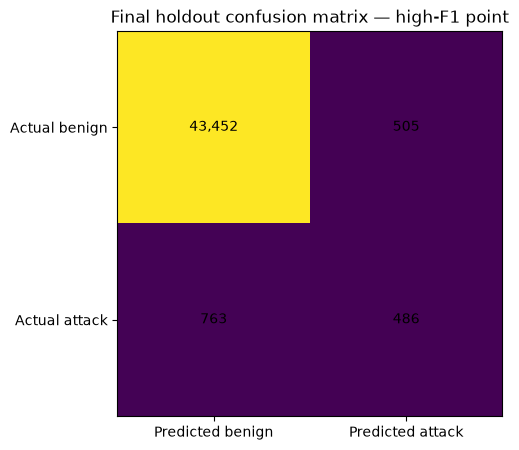

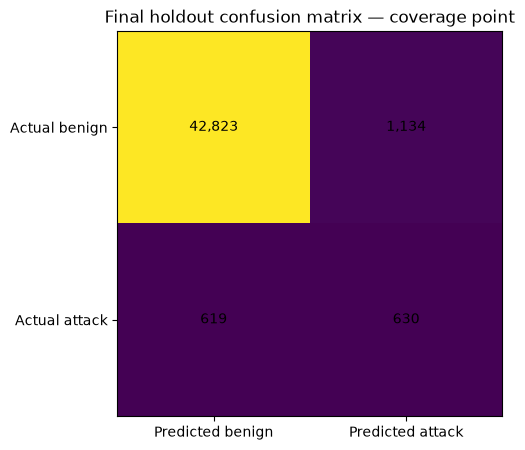

In [25]:
def plot_confusion(
    metrics: dict[str, float],
    title: str,
) -> None:
    matrix = np.array(
        [
            [
                metrics["tn"],
                metrics["fp"],
            ],
            [
                metrics["fn"],
                metrics["tp"],
            ],
        ]
    )

    fig, axis = plt.subplots(
        figsize=(6, 5)
    )

    axis.imshow(matrix)

    for row_index in range(2):
        for column_index in range(2):
            axis.text(
                column_index,
                row_index,
                f"{matrix[row_index, column_index]:,}",
                ha="center",
                va="center",
            )

    axis.set_xticks(
        [0, 1],
        [
            "Predicted benign",
            "Predicted attack",
        ],
    )

    axis.set_yticks(
        [0, 1],
        [
            "Actual benign",
            "Actual attack",
        ],
    )

    axis.set_title(title)
    plt.show()


plot_confusion(
    FINAL_HIGH_F1_METRICS,
    "Final holdout confusion matrix — high-F1 point",
)

plot_confusion(
    FINAL_COVERAGE_METRICS,
    "Final holdout confusion matrix — coverage point",
)

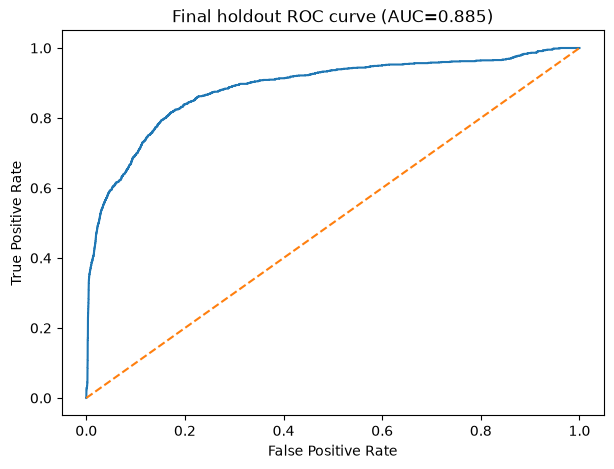

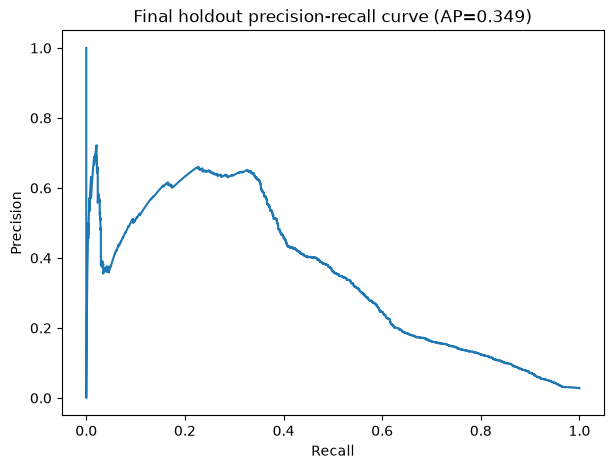

In [26]:
y_holdout = splits[
    "final_holdout"
]["is_attack"].to_numpy()

fpr_values, tpr_values, _ = roc_curve(
    y_holdout,
    ensemble_holdout_scores,
)

fig, axis = plt.subplots(
    figsize=(7, 5)
)

axis.plot(
    fpr_values,
    tpr_values,
)

axis.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
)

axis.set_xlabel(
    "False Positive Rate"
)

axis.set_ylabel(
    "True Positive Rate"
)

axis.set_title(
    "Final holdout ROC curve "
    f"(AUC={FINAL_COVERAGE_METRICS['roc_auc']:.3f})"
)

plt.show()

precision_values, recall_values, _ = (
    precision_recall_curve(
        y_holdout,
        ensemble_holdout_scores,
    )
)

fig, axis = plt.subplots(
    figsize=(7, 5)
)

axis.plot(
    recall_values,
    precision_values,
)

axis.set_xlabel("Recall")
axis.set_ylabel("Precision")

axis.set_title(
    "Final holdout precision-recall curve "
    f"(AP={FINAL_COVERAGE_METRICS['pr_auc']:.3f})"
)

plt.show()

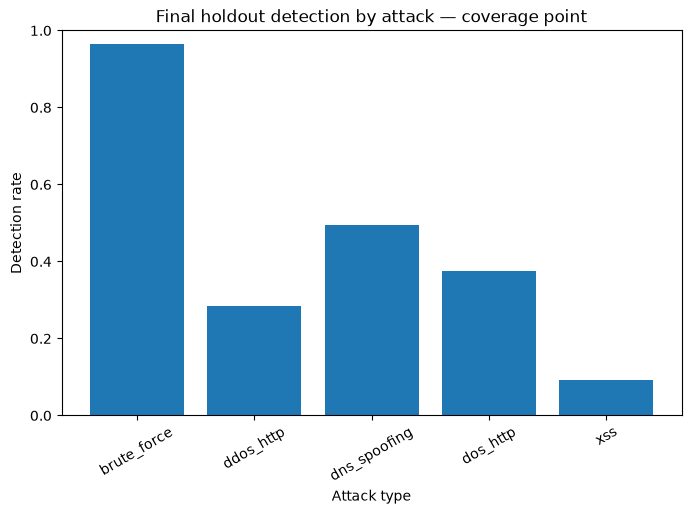

In [27]:
fig, axis = plt.subplots(
    figsize=(8, 5)
)

axis.bar(
    FINAL_COVERAGE_PER_ATTACK[
        "traffic_type"
    ],
    FINAL_COVERAGE_PER_ATTACK[
        "detection_rate"
    ],
)

axis.set_ylim(0, 1)
axis.set_ylabel("Detection rate")
axis.set_xlabel("Attack type")
axis.set_title(
    "Final holdout detection by attack — coverage point"
)
axis.tick_params(
    axis="x",
    rotation=30,
)

plt.show()

## 18. Save Phase 2 validation outputs

The notebook saves:

- feature-list screening results;
- model-tuning results;
- stability results;
- validation thresholds;
- final holdout comparisons;
- per-attack detection rates;
- the recommended feature list;
- a Phase 2 validation summary;
- packet-level anomaly scores;
- initial Phase 2 alerts.

All output files are written to:

```text
results/phase2_kmeans_validation/
```

In [28]:
if SAVE_RESULTS:
    output_directory = (
        REPO_ROOT
        / "results"
        / "phase2_kmeans_validation"
    )

    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    stage1_results.to_csv(
        output_directory
        / "stage1_feature_list_screening.csv",
        index=False,
    )

    feature_list_ranking.to_csv(
        output_directory
        / "feature_list_ranking.csv",
        index=False,
    )

    stage2_results.to_csv(
        output_directory
        / "stage2_model_tuning.csv",
        index=False,
    )

    stability_results.to_csv(
        output_directory
        / "pipeline_seed_stability.csv",
        index=False,
    )

    stable_pipeline_ranking.to_csv(
        output_directory
        / "stable_pipeline_ranking.csv",
        index=False,
    )

    FINAL_THRESHOLD_TABLE.to_csv(
        output_directory
        / "final_validation_thresholds.csv",
        index=False,
    )

    FINAL_COMPARISON.to_csv(
        output_directory
        / "final_holdout_comparison.csv",
        index=False,
    )

    FINAL_HIGH_F1_PER_ATTACK.to_csv(
        output_directory
        / "high_f1_per_attack.csv",
        index=False,
    )

    FINAL_COVERAGE_PER_ATTACK.to_csv(
        output_directory
        / "coverage_per_attack.csv",
        index=False,
    )

    (
        output_directory
        / "recommended_feature_list.json"
    ).write_text(
        json.dumps(
            FINAL_FEATURE_LIST,
            indent=2,
        ),
        encoding="utf-8",
    )

    (
        output_directory
        / "phase2_validation_summary.json"
    ).write_text(
        json.dumps(
            PHASE2_VALIDATION_SUMMARY,
            indent=2,
        ),
        encoding="utf-8",
    )

    alerts = splits[
        "final_holdout"
    ][
        [
            "source_file",
            "source_row_index",
            "stream",
            "group_id",
            "traffic_type",
            "is_attack",
        ]
    ].copy()

    alerts[
        "ensemble_anomaly_score"
    ] = ensemble_holdout_scores

    alerts[
        "high_f1_threshold"
    ] = FINAL_HIGH_F1_POINT[
        "threshold"
    ]

    alerts[
        "coverage_threshold"
    ] = FINAL_COVERAGE_POINT[
        "threshold"
    ]

    alerts[
        "high_f1_alert"
    ] = (
        alerts[
            "ensemble_anomaly_score"
        ]
        >= alerts[
            "high_f1_threshold"
        ]
    ).astype(int)

    alerts[
        "coverage_alert"
    ] = (
        alerts[
            "ensemble_anomaly_score"
        ]
        >= alerts[
            "coverage_threshold"
        ]
    ).astype(int)

    alerts.to_csv(
        output_directory
        / "final_holdout_packet_scores.csv",
        index=False,
    )

    alerts[
        alerts[
            "coverage_alert"
        ]
        == 1
    ].to_csv(
        output_directory
        / "phase2_initial_alerts.csv",
        index=False,
    )

    summary_lines = [
        "# Phase 2 Feature List Validation Summary",
        "",
        "## Status",
        PHASE2_VALIDATION_SUMMARY["status"],
        "",
        "## Selected feature list",
        FINAL_FEATURE_LIST_NAME,
        "",
        *[
            f"- {feature}"
            for feature in FINAL_FEATURE_LIST
        ],
        "",
        "## Selected pipeline",
        (
            f"{FINAL_MODEL_NAME} "
            f"{FINAL_MODEL_PARAMETERS}"
        ),
        (
            f"Three-seed score ensemble: "
            f"{MODEL_SEEDS}"
        ),
        "",
        "## Final holdout — high-F1 operating point",
        (
            f"- Accuracy: "
            f"{FINAL_HIGH_F1_METRICS['accuracy']:.4f}"
        ),
        (
            f"- Precision: "
            f"{FINAL_HIGH_F1_METRICS['precision']:.4f}"
        ),
        (
            f"- Recall: "
            f"{FINAL_HIGH_F1_METRICS['recall']:.4f}"
        ),
        (
            f"- F1: "
            f"{FINAL_HIGH_F1_METRICS['f1']:.4f}"
        ),
        (
            f"- FPR: "
            f"{FINAL_HIGH_F1_METRICS['fpr']:.4f}"
        ),
        (
            f"- ROC-AUC: "
            f"{FINAL_HIGH_F1_METRICS['roc_auc']:.4f}"
        ),
        (
            f"- PR-AUC: "
            f"{FINAL_HIGH_F1_METRICS['pr_auc']:.4f}"
        ),
        "",
        "## Final holdout — coverage operating point",
        (
            f"- Accuracy: "
            f"{FINAL_COVERAGE_METRICS['accuracy']:.4f}"
        ),
        (
            f"- Precision: "
            f"{FINAL_COVERAGE_METRICS['precision']:.4f}"
        ),
        (
            f"- Recall: "
            f"{FINAL_COVERAGE_METRICS['recall']:.4f}"
        ),
        (
            f"- F1: "
            f"{FINAL_COVERAGE_METRICS['f1']:.4f}"
        ),
        (
            f"- FPR: "
            f"{FINAL_COVERAGE_METRICS['fpr']:.4f}"
        ),
        (
            f"- Macro attack recall: "
            f"{FINAL_COVERAGE_METRICS['macro_attack_recall']:.4f}"
        ),
        (
            f"- Minimum attack recall: "
            f"{FINAL_COVERAGE_METRICS['minimum_attack_recall']:.4f}"
        ),
        (
            f"- ROC-AUC: "
            f"{FINAL_COVERAGE_METRICS['roc_auc']:.4f}"
        ),
        (
            f"- PR-AUC: "
            f"{FINAL_COVERAGE_METRICS['pr_auc']:.4f}"
        ),
        "",
        "## Weak attack types",
        str(weak_attacks),
        "",
        "## Interpretation",
        (
            "The feature candidate was selected using "
            "development data across multiple model families "
            "and random seeds. The final holdout was evaluated "
            "only after the pipeline and thresholds were frozen."
        ),
    ]

    (
        output_directory
        / "PHASE2_VALIDATION_SUMMARY.md"
    ).write_text(
        "\n".join(summary_lines),
        encoding="utf-8",
    )

    print(
        "Saved Phase 2 validation outputs to:",
        output_directory,
    )

Saved Phase 2 validation outputs to: C:\Users\7pixe\Music\ECE597-Capstone-IoT-IDS\results\phase2_kmeans_validation


## How to use this validation result

Use the final printed status as the summary of this experiment:

- **RECOMMENDED PHASE 2 FEATURE CANDIDATE:** the selected feature list performed at least as well as the best original Top-10 baseline under the same validation procedure.
- **ORIGINAL TOP-10 PERFORMED BETTER IN THIS VALIDATION:** the original Top-10 remains the safer candidate for this experiment.

The selected list is a team-facing Phase 2 candidate. Other team members may still compare it with alternative feature lists or models.

Do not modify the feature list after inspecting the final holdout result from this run.